### **1. Isotropic Covariance Matrix**

In [294]:
import numpy as np
import matplotlib.pyplot as plt
from src.distributions import gaussian

In [295]:
rng = np.random.default_rng(42) # fixing seed 42

# hand picked mu and sigma as 1
n = 1000
mu = np.array([2, 4])
sigma = 1

x1 = gaussian(mu[0], sigma, n, rng)
x2 = gaussian(mu[1], sigma, n, rng)

X = np.column_stack((x1, x2))

In [296]:
print("Shape:", X.shape)
print("Target mean:", mu)
print("Sample mean:", X.mean(axis=0))

Shape: (1000, 2)
Target mean: [2 4]
Sample mean: [1.98413382 3.9676051 ]


In [297]:
X[:5]

array([[3.48320678, 4.5753355 ],
       [1.66908592, 2.10384994],
       [2.78377812, 2.4803518 ],
       [2.43138215, 2.8040629 ],
       [2.68134042, 5.4946898 ]])

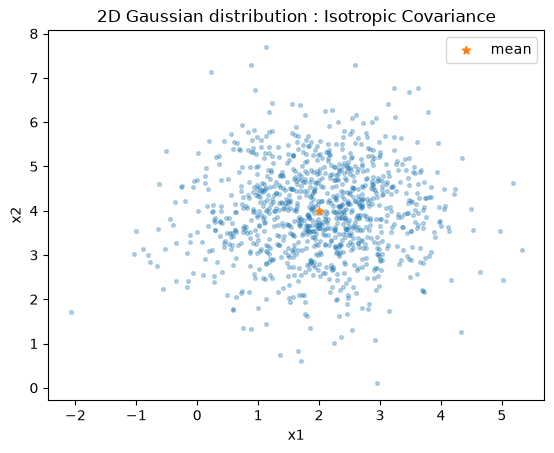

In [298]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, s=7)
plt.scatter(mu[0], mu[1], marker="*", label="mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Gaussian distribution : Isotropic Covariance")
plt.legend()
plt.show()

In [299]:
# computing the covariance matrix using numpy

mu_hat = np.array([X[:, 0].mean(), X[:, 1].mean()])
C_est = np.cov(X, rowvar=False)
C_est

array([[1.03800245, 0.04634667],
       [0.04634667, 1.07517189]])

In [300]:
# computing the eigenvalues and eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(C_est)

# order them in descending
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Eigen values:", eigenvalues)
print("Eigen vectors:\n", eigenvectors)


Eigen values: [1.10652119 1.00665316]
Eigen vectors:
 [[ 0.56027422 -0.82830719]
 [ 0.82830719  0.56027422]]


In [301]:
# forming a meshgrid

# [mu - 4.sigma to mu + 4.sigma]
x = np.linspace(x1.mean() - 4 * x1.std(), x1.mean() + 4 * x1.std(), 200)
y = np.linspace(x2.mean() - 4 * x2.std(), x2.mean() + 4 * x2.std(), 200)

x_grid, y_grid = np.meshgrid(x, y)

C_est_inv = np.linalg.inv(C_est)
q_grid = np.zeros(x_grid.shape)
mean = mu_hat.reshape(2, 1)

for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([
            [x_grid[i, j]],
            [y_grid[i, j]]
        ])

        deviation = point - mean

        q_grid[i, j] = (deviation.T @ C_est_inv @ deviation).item()


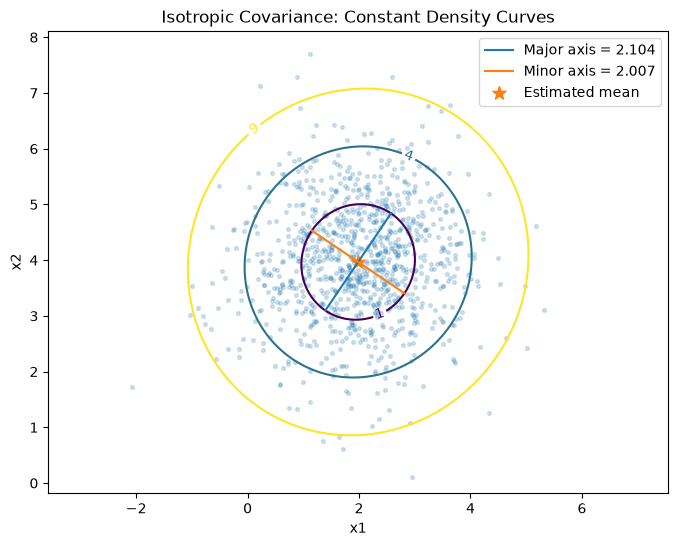

In [302]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.2, s=7)

contours = plt.contour(x_grid, y_grid, q_grid, levels=[1, 4, 9])
plt.clabel(contours)

major_vector = np.sqrt(eigenvalues[0]) * eigenvectors[:, 0]
minor_vector = np.sqrt(eigenvalues[1]) * eigenvectors[:, 1]

major_axis_length = 2 * np.sqrt(eigenvalues[0])
minor_axis_length = 2 * np.sqrt(eigenvalues[1])

plt.plot(
    [mu_hat[0] - major_vector[0], mu_hat[0] + major_vector[0]],
    [mu_hat[1] - major_vector[1], mu_hat[1] + major_vector[1]],
    label=f"Major axis = {major_axis_length:.3f}"
)

plt.plot(
    [mu_hat[0] - minor_vector[0], mu_hat[0] + minor_vector[0]],
    [mu_hat[1] - minor_vector[1], mu_hat[1] + minor_vector[1]],
    label=f"Minor axis = {minor_axis_length:.3f}"
)

plt.scatter(mu_hat[0], mu_hat[1], marker="*", s=100, label="Estimated mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Isotropic Covariance: Constant Density Curves")
plt.legend()
plt.axis("equal")
plt.show()

### **Diagonal Covariance Matrix**

In [303]:
C_diag = np.array([[4, 0], 
                   [0, 1]])

C_sqrt = np.sqrt(C_diag)

# sample points scaled (std) and centered around the mean
Y = mu + (X - mu) @ C_sqrt

In [304]:
print(Y.shape)
print(Y.mean(axis=0))

(1000, 2)
[1.96826763 3.9676051 ]


In [305]:
# estimated mean and covariance

mu_diag_hat = Y.mean(axis=0)
C_diag_est = np.cov(Y, rowvar=False)

C_diag_est

array([[4.15200981, 0.09269334],
       [0.09269334, 1.07517189]])

In [306]:
# eigenvalues and eigenvectors

diag_eigenvalues, diag_eigenvectors = np.linalg.eigh(C_diag_est)

sorted_idx = np.argsort(diag_eigenvalues)[::-1]
diag_eigenvalues = diag_eigenvalues[sorted_idx]
diag_eigenvectors = diag_eigenvectors[:, sorted_idx]

print("Eigenvalues:", diag_eigenvalues)
print("Eigenvectors:\n", diag_eigenvectors)

Eigenvalues: [4.15479978 1.07238193]
Eigenvectors:
 [[-0.99954734  0.03008525]
 [-0.03008525 -0.99954734]]


In [307]:
# meshgrid and squared Mahalanobis distance

x_diag = np.linspace(Y[:, 0].mean() - 4 * Y[:, 0].std(), Y[:, 0].mean() + 4 * Y[:, 0].std(), 200)
y_diag = np.linspace(Y[:, 1].mean() - 4 * Y[:, 1].std(), Y[:, 1].mean() + 4 * Y[:, 1].std(), 200)

x_diag_grid, y_diag_grid = np.meshgrid(x_diag, y_diag)

C_diag_inv = np.linalg.inv(C_diag_est)
q_diag_grid = np.zeros(x_diag_grid.shape)
diag_mean = mu_diag_hat.reshape(2, 1)

for i in range(x_diag_grid.shape[0]):
    for j in range(x_diag_grid.shape[1]):
        point = np.array([
            [x_diag_grid[i, j]],
            [y_diag_grid[i, j]]
        ])

        deviation = point - diag_mean
        q_diag_grid[i, j] = (deviation.T @ C_diag_inv @ deviation).item()

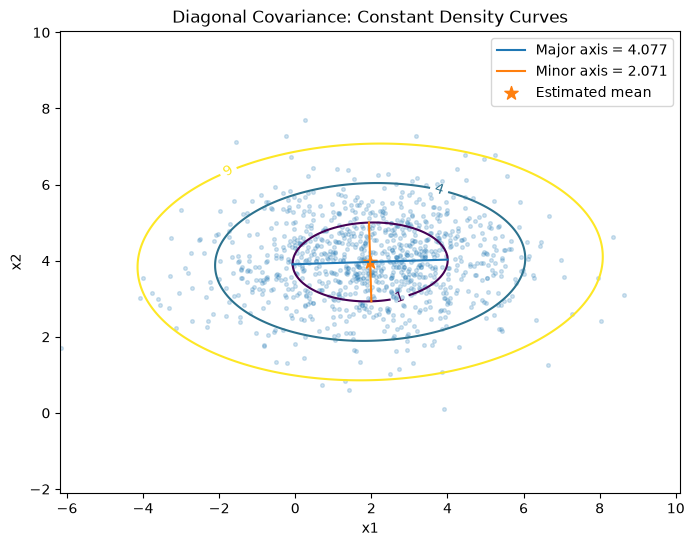

In [308]:
plt.figure(figsize=(8, 6))
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.2, s=7)

diag_contours = plt.contour(x_diag_grid, y_diag_grid, q_diag_grid, levels=[1, 4, 9])
plt.clabel(diag_contours)

diag_major_vector = np.sqrt(diag_eigenvalues[0]) * diag_eigenvectors[:, 0]
diag_minor_vector = np.sqrt(diag_eigenvalues[1]) * diag_eigenvectors[:, 1]

diag_major_axis_length = 2 * np.sqrt(diag_eigenvalues[0])
diag_minor_axis_length = 2 * np.sqrt(diag_eigenvalues[1])

plt.plot(
    [mu_diag_hat[0] - diag_major_vector[0], mu_diag_hat[0] + diag_major_vector[0]],
    [mu_diag_hat[1] - diag_major_vector[1], mu_diag_hat[1] + diag_major_vector[1]],
    label=f"Major axis = {diag_major_axis_length:.3f}"
)

plt.plot(
    [mu_diag_hat[0] - diag_minor_vector[0], mu_diag_hat[0] + diag_minor_vector[0]],
    [mu_diag_hat[1] - diag_minor_vector[1], mu_diag_hat[1] + diag_minor_vector[1]],
    label=f"Minor axis = {diag_minor_axis_length:.3f}"
)

plt.scatter(mu_diag_hat[0], mu_diag_hat[1], marker="*", s=100, label="Estimated mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Diagonal Covariance: Constant Density Curves")
plt.legend()
plt.axis("equal")
plt.show()

### **Full Covariance Matrix**

In [309]:
# full covariance matrix
C_full = np.array([[4.0, 1.5],
                   [1.5, 1.0]])

C_full_eigenvalues, C_full_eigenvectors = np.linalg.eigh(C_full)
C_full_sqrt = C_full_eigenvectors @ np.diag(np.sqrt(C_full_eigenvalues)) @ C_full_eigenvectors.T

Y_full = mu + (X - mu) @ C_full_sqrt.T

In [310]:
C_full_sqrt

array([[1.92502439, 0.54247681],
       [0.54247681, 0.84007078]])

In [311]:
print(Y_full.shape)
print(Y_full.mean(axis=0))

(1000, 2)
[1.95188373 3.96417895]


In [312]:
# estimated mean and covariance

mu_full_hat = Y_full.mean(axis=0)
C_full_est = np.cov(Y_full, rowvar=False)

C_full_est

array([[4.25974598, 1.66253127],
       [1.66253127, 1.10647574]])

In [313]:
# eigenvalues and eigenvectors

full_eigenvalues, full_eigenvectors = np.linalg.eigh(C_full_est)

sorted_idx = np.argsort(full_eigenvalues)[::-1]
full_eigenvalues = full_eigenvalues[sorted_idx]
full_eigenvectors = full_eigenvectors[:, sorted_idx]

print("Eigenvalues:", full_eigenvalues)
print("Eigenvectors:\n", full_eigenvectors)

Eigenvalues: [4.97435256 0.39186916]
Eigenvectors:
 [[-0.9187257   0.39489629]
 [-0.39489629 -0.9187257 ]]


In [314]:
# meshgrid and squared Mahalanobis distance

x_full = np.linspace(Y_full[:, 0].mean() - 4 * Y_full[:, 0].std(), Y_full[:, 0].mean() + 4 * Y_full[:, 0].std(), 200)
y_full = np.linspace(Y_full[:, 1].mean() - 4 * Y_full[:, 1].std(), Y_full[:, 1].mean() + 4 * Y_full[:, 1].std(), 200)

x_full_grid, y_full_grid = np.meshgrid(x_full, y_full)

C_full_inv = np.linalg.inv(C_full_est)
q_full_grid = np.zeros(x_full_grid.shape)
full_mean = mu_full_hat.reshape(2, 1)

for i in range(x_full_grid.shape[0]):
    for j in range(x_full_grid.shape[1]):
        point = np.array([
            [x_full_grid[i, j]],
            [y_full_grid[i, j]]
        ])

        deviation = point - full_mean
        q_full_grid[i, j] = (deviation.T @ C_full_inv @ deviation).item()

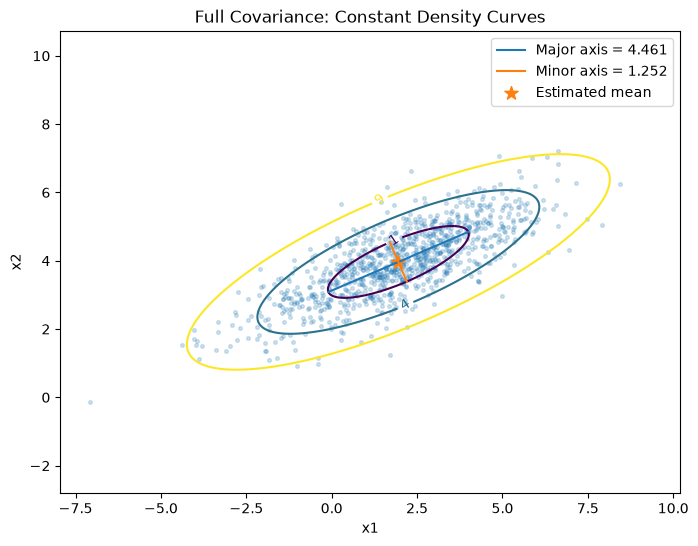

In [315]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_full[:, 0], Y_full[:, 1], alpha=0.2, s=7)

full_contours = plt.contour(x_full_grid, y_full_grid, q_full_grid, levels=[1, 4, 9])
plt.clabel(full_contours)

full_major_vector = np.sqrt(full_eigenvalues[0]) * full_eigenvectors[:, 0]
full_minor_vector = np.sqrt(full_eigenvalues[1]) * full_eigenvectors[:, 1]

full_major_axis_length = 2 * np.sqrt(full_eigenvalues[0])
full_minor_axis_length = 2 * np.sqrt(full_eigenvalues[1])

plt.plot(
    [mu_full_hat[0] - full_major_vector[0], mu_full_hat[0] + full_major_vector[0]],
    [mu_full_hat[1] - full_major_vector[1], mu_full_hat[1] + full_major_vector[1]],
    label=f"Major axis = {full_major_axis_length:.3f}"
)

plt.plot(
    [mu_full_hat[0] - full_minor_vector[0], mu_full_hat[0] + full_minor_vector[0]],
    [mu_full_hat[1] - full_minor_vector[1], mu_full_hat[1] + full_minor_vector[1]],
    label=f"Minor axis = {full_minor_axis_length:.3f}"
)

plt.scatter(mu_full_hat[0], mu_full_hat[1], marker="*", s=100, label="Estimated mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Full Covariance: Constant Density Curves")
plt.legend()
plt.axis("equal")
plt.show()

### **Two Gaussian Classes**

##### **Equal Covariance Matrices**

In [316]:
mu_1 = np.array([0.0, 0.0])
mu_2 = np.array([4.0, 4.0])

C_1 = np.array([[1.0, 0.0],
                [0.0, 1.0]])

C_2 = np.array([[1.0, 0.0],
                [0.0, 1.0]])

In [317]:
class_rng = np.random.default_rng(42)

Y_1 = np.column_stack((
    gaussian(mu_1[0], 1, n, class_rng),
    gaussian(mu_1[1], 1, n, class_rng)
))

Y_2 = np.column_stack((
    gaussian(mu_2[0], 1, n, class_rng),
    gaussian(mu_2[1], 1, n, class_rng)
))

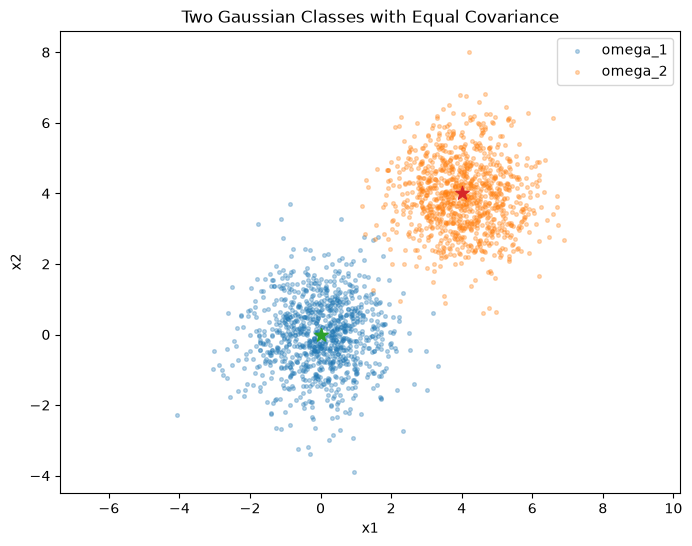

In [318]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_1[:, 0], Y_1[:, 1], alpha=0.3, s=7, label="omega_1")
plt.scatter(Y_2[:, 0], Y_2[:, 1], alpha=0.3, s=7, label="omega_2")
plt.scatter(mu_1[0], mu_1[1], marker="*", s=100)
plt.scatter(mu_2[0], mu_2[1], marker="*", s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Gaussian Classes with Equal Covariance")
plt.legend()
plt.axis("equal")
plt.show()

In [319]:
# grid for the decision boundary

x_decision = np.linspace(-4, 8, 200)
y_decision = np.linspace(-4, 8, 200)
x_decision_grid, y_decision_grid = np.meshgrid(x_decision, y_decision)

g_1 = np.zeros(x_decision_grid.shape)
g_2 = np.zeros(x_decision_grid.shape)

C_1_inv = np.linalg.inv(C_1)
C_2_inv = np.linalg.inv(C_2)

In [320]:
# discriminant score for each class

mean_1 = mu_1.reshape(2, 1)
mean_2 = mu_2.reshape(2, 1)

for i in range(x_decision_grid.shape[0]):
    for j in range(x_decision_grid.shape[1]):
        point = np.array([
            [x_decision_grid[i, j]],
            [y_decision_grid[i, j]]
        ])

        deviation_1 = point - mean_1
        deviation_2 = point - mean_2

        g_1[i, j] = -0.5 * (deviation_1.T @ C_1_inv @ deviation_1).item()
        g_2[i, j] = -0.5 * (deviation_2.T @ C_2_inv @ deviation_2).item()

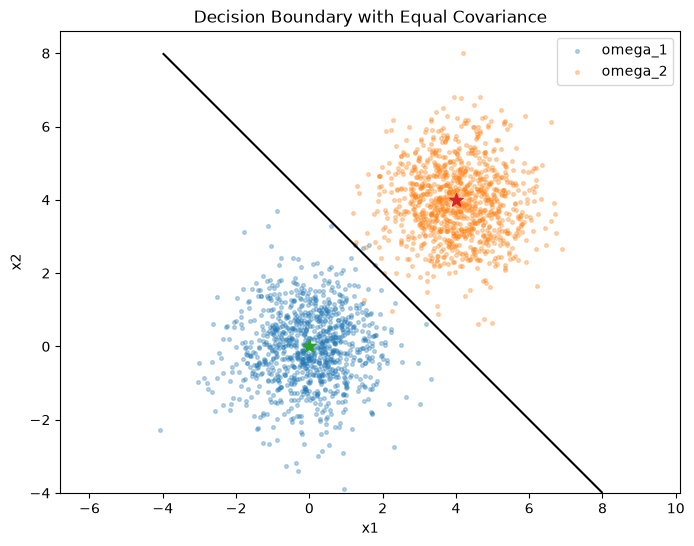

In [321]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_1[:, 0], Y_1[:, 1], alpha=0.3, s=7, label="omega_1")
plt.scatter(Y_2[:, 0], Y_2[:, 1], alpha=0.3, s=7, label="omega_2")

boundary = plt.contour(
    x_decision_grid,
    y_decision_grid,
    g_1 - g_2,
    levels=[0],
    colors="black"
)
plt.scatter(mu_1[0], mu_1[1], marker="*", s=100)
plt.scatter(mu_2[0], mu_2[1], marker="*", s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary with Equal Covariance")
plt.legend()
plt.axis("equal")
plt.show()

#### **Different Covariance Matrices**

In [344]:
C_1_unequal = np.array([[1.0, 0.0],
                        [0.0, 1.0]])

C_2_unequal = np.array([[4.0, 1.5],
                        [1.5, 2.0]])

In [345]:
C_2_values, C_2_vectors = np.linalg.eigh(C_2_unequal)
C_2_unequal_sqrt = C_2_vectors @ np.diag(np.sqrt(C_2_values)) @ C_2_vectors.T

In [346]:
unequal_rng = np.random.default_rng(43)
Z_2 = np.column_stack((
    gaussian(0, 1, n, unequal_rng),
    gaussian(0, 1, n, unequal_rng)
))

Y_2_unequal = mu_2 + Z_2 @ C_2_unequal_sqrt.T

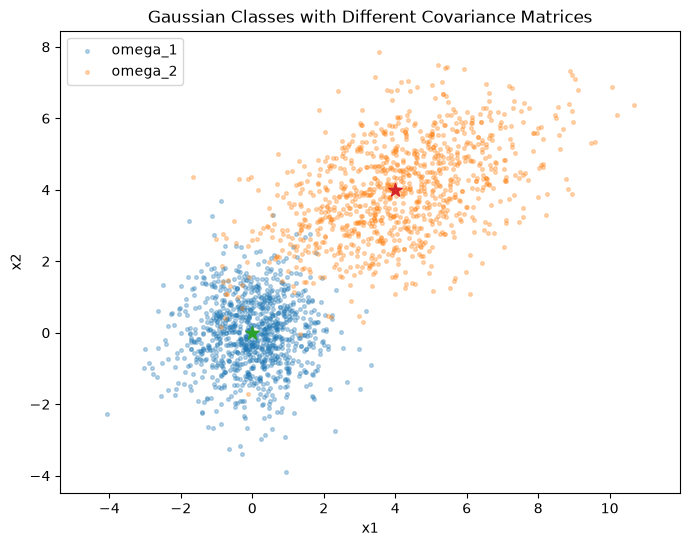

In [347]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_1[:, 0], Y_1[:, 1], alpha=0.3, s=7, label="omega_1")
plt.scatter(Y_2_unequal[:, 0], Y_2_unequal[:, 1], alpha=0.3, s=7, label="omega_2")
plt.scatter(mu_1[0], mu_1[1], marker="*", s=100)
plt.scatter(mu_2[0], mu_2[1], marker="*", s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Gaussian Classes with Different Covariance Matrices")
plt.legend()
plt.axis("equal")
plt.show()

In [348]:
C_1_unequal_inv = np.linalg.inv(C_1_unequal)
C_2_unequal_inv = np.linalg.inv(C_2_unequal)

C_1_log_det = np.log(np.linalg.det(C_1_unequal))
C_2_log_det = np.log(np.linalg.det(C_2_unequal))

g_1_unequal = np.zeros_like(x_decision_grid)
g_2_unequal = np.zeros_like(x_decision_grid)

In [349]:
for i in range(x_decision_grid.shape[0]):
    for j in range(x_decision_grid.shape[1]):
        point = np.array([[x_decision_grid[i, j]],
                          [y_decision_grid[i, j]]])

        deviation_1 = point - mean_1
        deviation_2 = point - mean_2

        g_1_unequal[i, j] = (-0.5 * (deviation_1.T @ C_1_unequal_inv @ deviation_1).item()
                              - 0.5 * C_1_log_det)
        g_2_unequal[i, j] = (-0.5 * (deviation_2.T @ C_2_unequal_inv @ deviation_2).item()
                              - 0.5 * C_2_log_det)

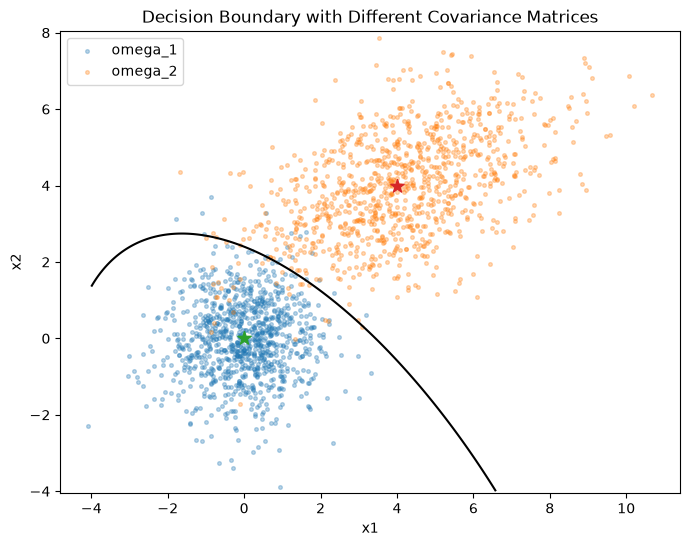

In [350]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_1[:, 0], Y_1[:, 1], alpha=0.3, s=7, label="omega_1")
plt.scatter(Y_2_unequal[:, 0], Y_2_unequal[:, 1], alpha=0.3, s=7, label="omega_2")

plt.contour(
    x_decision_grid,
    y_decision_grid,
    g_1_unequal - g_2_unequal,
    levels=[0],
    colors="black"
)
plt.scatter(mu_1[0], mu_1[1], marker="*", s=100)
plt.scatter(mu_2[0], mu_2[1], marker="*", s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary with Different Covariance Matrices")
plt.legend()
plt.axis("equal")
plt.show()